In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import zipfile
with zipfile.ZipFile("/content/dataset 2.zip", 'r') as zip_ref:
    zip_ref.extractall("/content/")

print("Dataset successfully unzipped into Colab's local storage.")

Dataset successfully unzipped into Colab's local storage.


In [ ]:
import os
import cv2
import numpy as np
from tqdm import tqdm


base_path = '/content/dataset'



train_masks_path = os.path.join(base_path, 'train', 'masks')
val_masks_path = os.path.join(base_path, 'val', 'masks')
test_masks_path = os.path.join(base_path, 'test', 'masks')

print(f"Train masks path exists: {os.path.exists(train_masks_path)}")
print(f"Validation masks path exists: {os.path.exists(val_masks_path)}")
print(f"Test masks path exists: {os.path.exists(test_masks_path)}")

Train masks path exists: True
Validation masks path exists: True
Test masks path exists: True


Inspecting colors in: /content/dataset/train/masks/Oil (861).png

Found the following unique colors in the mask:

- BGR Value: [0 0 0] | Pixel Count: 46266


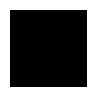


- BGR Value: [ 51 204 255] | Pixel Count: 1021405


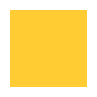


- BGR Value: [124   0 255] | Pixel Count: 607294


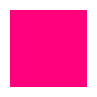


- BGR Value: [255 221  51] | Pixel Count: 398635


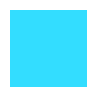

In [ ]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt

known_spill_mask_filename = 'Oil (861).png'

path_to_mask = os.path.join(train_masks_path, known_spill_mask_filename)


print(f"Inspecting colors in: {path_to_mask}\n")


mask = cv2.imread(path_to_mask, cv2.IMREAD_COLOR)

if mask is None:
    print("ERROR: Could not read the image. Please check the filename and path.")
else:

    pixels = mask.reshape(-1, 3)


    unique_colors, counts = np.unique(pixels, axis=0, return_counts=True)

    print("Found the following unique colors in the mask:")
    for i, color_bgr in enumerate(unique_colors):
        count = counts[i]


        color_rgb = color_bgr[::-1]

        print(f"\n- BGR Value: {color_bgr} | Pixel Count: {count}")


        plt.figure(figsize=(1, 1))
        plt.imshow([[color_rgb]])
        plt.axis('off')
        plt.show()

In [ ]:
def count_spill_images(mask_directory):

    OIL_SPILL_COLOR_BGR = np.array([124, 0, 255])

    spill_count = 0
    no_spill_count = 0

    mask_files = [f for f in os.listdir(mask_directory) if f.endswith('.png')]

    print(f"\nAnalyzing masks in: {mask_directory}")
    for filename in tqdm(mask_files):
        img_path = os.path.join(mask_directory, filename)


        mask = cv2.imread(img_path, cv2.IMREAD_COLOR)

        if mask is None:
            print(f"Warning: Could not read {filename}. Skipping.")
            continue


        if np.any(np.all(mask == OIL_SPILL_COLOR_BGR, axis=2)):
            spill_count += 1
        else:
            no_spill_count += 1

    return (spill_count, no_spill_count)

In [ ]:
train_spills, train_no_spills = count_spill_images(train_masks_path)
total_train = train_spills + train_no_spills

val_spills, val_no_spills = count_spill_images(val_masks_path)
total_val = val_spills + val_no_spills

test_spills, test_no_spills = count_spill_images(test_masks_path)
total_test = test_spills + test_no_spills

print("\n" + "="*30)
print("      DATASET SUMMARY")
print("="*30)
print(f"Training Set:")
print(f"  - Images with Oil Spill:    {train_spills} ({train_spills/total_train:.2%})")
print(f"  - Images with No Oil Spill: {train_no_spills} ({train_no_spills/total_train:.2%})")
print(f"  - Total:                    {total_train}")
print("-"*30)
print(f"Validation Set:")
print(f"  - Images with Oil Spill:    {val_spills} ({val_spills/total_val:.2%})")
print(f"  - Images with No Oil Spill: {val_no_spills} ({val_no_spills/total_val:.2%})")
print(f"  - Total:                    {total_val}")
print("-"*30)
print(f"Test Set:")
print(f"  - Images with Oil Spill:    {test_spills} ({test_spills/total_test:.2%})")
print(f"  - Images with No Oil Spill: {test_no_spills} ({test_no_spills/total_test:.2%})")
print(f"  - Total:                    {total_test}")
print("="*30)


Analyzing masks in: /content/dataset/train/masks


100%|██████████| 810/810 [01:19<00:00, 10.23it/s]



Analyzing masks in: /content/dataset/val/masks


100%|██████████| 203/203 [00:18<00:00, 11.07it/s]



Analyzing masks in: /content/dataset/test/masks


100%|██████████| 254/254 [00:23<00:00, 10.69it/s]


      DATASET SUMMARY
Training Set:
  - Images with Oil Spill:    633 (78.15%)
  - Images with No Oil Spill: 177 (21.85%)
  - Total:                    810
------------------------------
Validation Set:
  - Images with Oil Spill:    163 (80.30%)
  - Images with No Oil Spill: 40 (19.70%)
  - Total:                    203
------------------------------
Test Set:
  - Images with Oil Spill:    202 (79.53%)
  - Images with No Oil Spill: 52 (20.47%)
  - Total:                    254


In [ ]:
!pip install -U albumentations

import torch
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
import cv2
import numpy as np
import os
from tqdm import tqdm

In [ ]:

OIL_SPILL_COLOR_BGR = np.array([124, 0, 255])

IMAGE_HEIGHT = 256
IMAGE_WIDTH = 256

no_spill_transform = A.Compose([
    A.Resize(height=IMAGE_HEIGHT, width=IMAGE_WIDTH),
    A.Rotate(limit=35, p=0.7),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),

    A.GaussNoise(p=0.2),
    A.RandomSunFlare(p=0.5, flare_roi=(0, 0, 1, 0.5), src_radius=100),
    A.CoarseDropout(max_holes=8, max_height=32, max_width=32, p=0.5),

    A.Normalize(mean=[0.0, 0.0, 0.0], std=[1.0, 1.0, 1.0], max_pixel_value=255.0),
    ToTensorV2(),
])

base_transform = A.Compose([
    A.Resize(height=IMAGE_HEIGHT, width=IMAGE_WIDTH),
    A.Normalize(
        mean=[0.0, 0.0, 0.0],
        std=[1.0, 1.0, 1.0],
        max_pixel_value=255.0,
    ),
    ToTensorV2(),
])

/tmp/ipython-input-1975687375.py:17: UserWarning: Argument(s) 'max_holes, max_height, max_width' are not valid for transform CoarseDropout
  A.CoarseDropout(max_holes=8, max_height=32, max_width=32, p=0.5),


In [ ]:
class OilSpillDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform_no_spill, transform_base):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.transform_no_spill = transform_no_spill
        self.transform_base = transform_base

        self.images = [f for f in os.listdir(image_dir) if f.endswith('.jpg')]

        print(f"Pre-scanning masks in {mask_dir} to identify 'no spill' images...")
        self.no_spill_indices = set()
        for idx, img_name in enumerate(tqdm(self.images)):
            mask_name = img_name.replace('.jpg', '.png')
            mask_path = os.path.join(self.mask_dir, mask_name)

            mask = cv2.imread(mask_path, cv2.IMREAD_COLOR)

            is_spill = False
            if mask is not None and mask.ndim == 3:
                if np.any(np.all(mask == OIL_SPILL_COLOR_BGR, axis=2)):
                    is_spill = True

            if not is_spill:
                self.no_spill_indices.add(idx)

        print(f"Scan complete. Found {len(self.no_spill_indices)} 'no spill' images.")

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]
        img_path = os.path.join(self.image_dir, img_name)
        mask_name = img_name.replace('.jpg', '.png')
        mask_path = os.path.join(self.mask_dir, mask_name)

        image = cv2.imread(img_path, cv2.IMREAD_COLOR)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        mask_color = cv2.imread(mask_path, cv2.IMREAD_COLOR)

        binary_mask = np.zeros((image.shape[0], image.shape[1]), dtype=np.float32)

        if mask_color is not None and mask_color.ndim == 3:
            spill_area = np.all(mask_color == OIL_SPILL_COLOR_BGR, axis=2)
            binary_mask[spill_area] = 1.0

        if idx in self.no_spill_indices:
            augmented = self.transform_no_spill(image=image, mask=binary_mask)
        else:
            augmented = self.transform_base(image=image, mask=binary_mask)

        image = augmented['image']
        mask = augmented['mask']

        return image, mask.unsqueeze(0)

In [ ]:
train_imgs_path = os.path.join(base_path, 'train', 'images')
val_imgs_path = os.path.join(base_path, 'val', 'images')

train_dataset = OilSpillDataset(
    image_dir=train_imgs_path,
    mask_dir=train_masks_path,
    transform_no_spill=no_spill_transform,
    transform_base=base_transform
)

val_dataset = OilSpillDataset(
    image_dir=val_imgs_path,
    mask_dir=val_masks_path,
    transform_no_spill=no_spill_transform, t
    transform_base=base_transform
)

BATCH_SIZE = 16
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print(f"\nDataLoaders created successfully!")
print(f"Number of training batches: {len(train_loader)}")
print(f"Number of validation batches: {len(val_loader)}")

Pre-scanning masks in /content/dataset/train/masks to identify 'no spill' images...


100%|██████████| 811/811 [01:28<00:00,  9.19it/s]


Scan complete. Found 178 'no spill' images.
Pre-scanning masks in /content/dataset/val/masks to identify 'no spill' images...


100%|██████████| 203/203 [00:19<00:00, 10.66it/s]

Scan complete. Found 40 'no spill' images.

DataLoaders created successfully!
Number of training batches: 51
Number of validation batches: 13


In [ ]:
from torch.utils.data import WeightedRandomSampler

train_imgs_path = os.path.join(base_path, 'train', 'images')
val_imgs_path = os.path.join(base_path, 'val', 'images')

train_dataset = OilSpillDataset(
    image_dir=train_imgs_path,
    mask_dir=train_masks_path,
    transform_no_spill=no_spill_transform,
    transform_base=base_transform
)

val_dataset = OilSpillDataset(
    image_dir=val_imgs_path,
    mask_dir=val_masks_path,
    transform_no_spill=no_spill_transform,
    transform_base=base_transform
)


print("\nCreating a weighted sampler to balance the training data...")

num_spill = len(train_dataset) - len(train_dataset.no_spill_indices)
num_no_spill = len(train_dataset.no_spill_indices)

spill_weight = 1.0 / num_spill
no_spill_weight = 1.0 / num_no_spill

sample_weights = []
for i in range(len(train_dataset)):
    if i in train_dataset.no_spill_indices:
        sample_weights.append(no_spill_weight)
    else:
        sample_weights.append(spill_weight)

sampler = WeightedRandomSampler(
    weights=torch.DoubleTensor(sample_weights),
    num_samples=len(train_dataset),
    replacement=True
)
print("Sampler created.")

BATCH_SIZE = 16
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=sampler
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print(f"\nDataLoaders created successfully!")
print(f"Number of training batches: {len(train_loader)}")
print(f"Number of validation batches: {len(val_loader)}")

Pre-scanning masks in /content/dataset/train/masks to identify 'no spill' images...


100%|██████████| 811/811 [01:28<00:00,  9.21it/s]


Scan complete. Found 178 'no spill' images.
Pre-scanning masks in /content/dataset/val/masks to identify 'no spill' images...


100%|██████████| 203/203 [00:19<00:00, 10.43it/s]

Scan complete. Found 40 'no spill' images.

Creating a weighted sampler to balance the training data...
Sampler created.

DataLoaders created successfully!
Number of training batches: 51
Number of validation batches: 13


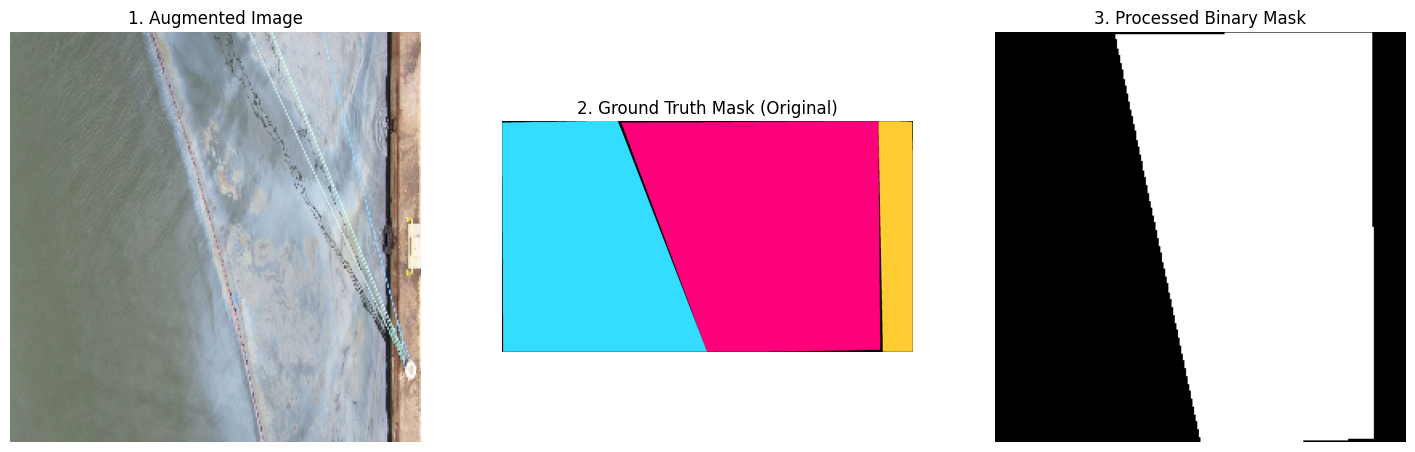

In [ ]:
import matplotlib.pyplot as plt
import cv2
import os

idx_to_visualize = 10

augmented_image, processed_mask = train_dataset[idx_to_visualize]

img_name = train_dataset.images[idx_to_visualize]
mask_name = img_name.replace('.jpg', '.png')
mask_path = os.path.join(train_masks_path, mask_name)
ground_truth_mask = cv2.imread(mask_path, cv2.IMREAD_COLOR)
ground_truth_mask = cv2.cvtColor(ground_truth_mask, cv2.COLOR_BGR2RGB)


augmented_image_vis = augmented_image.permute(1, 2, 0).numpy()
processed_mask_vis = processed_mask.squeeze(0).numpy()


fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))

ax1.imshow(augmented_image_vis)
ax1.set_title("1. Augmented Image")
ax1.axis("off")

ax2.imshow(ground_truth_mask)
ax2.set_title("2. Ground Truth Mask (Original)")
ax2.axis("off")

ax3.imshow(processed_mask_vis, cmap='gray')
ax3.set_title("3. Processed Binary Mask")
ax3.axis("off")

plt.show()

In [ ]:
import torch
import torch.nn as nn
import torchvision.transforms.functional as TF

class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(DoubleConv, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, 1, 1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, 1, 1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.conv(x)

class UNET(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, features=[64, 128, 256, 512]):
        super(UNET, self).__init__()
        self.ups = nn.ModuleList()
        self.downs = nn.ModuleList()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        for feature in features:
            self.downs.append(DoubleConv(in_channels, feature))
            in_channels = feature

        for feature in reversed(features):
            self.ups.append(
                nn.ConvTranspose2d(
                    feature*2, feature, kernel_size=2, stride=2,
                )
            )
            self.ups.append(DoubleConv(feature*2, feature))

        self.bottleneck = DoubleConv(features[-1], features[-1]*2)
        self.final_conv = nn.Conv2d(features[0], out_channels, kernel_size=1)

    def forward(self, x):
        skip_connections = []


        for down in self.downs:
            x = down(x)
            skip_connections.append(x)
            x = self.pool(x)

        x = self.bottleneck(x)
        skip_connections = skip_connections[::-1]
        for idx in range(0, len(self.ups), 2):
            x = self.ups[idx](x)
            skip_connection = skip_connections[idx//2]

            if x.shape != skip_connection.shape:
                x = TF.resize(x, size=skip_connection.shape[2:])

            concat_skip = torch.cat((skip_connection, x), dim=1)
            x = self.ups[idx+1](concat_skip)

        return self.final_conv(x)

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using {device} device.")

model = UNET(in_channels=3, out_channels=1).to(device)

dummy_input = torch.randn(BATCH_SIZE, 3, IMAGE_HEIGHT, IMAGE_WIDTH).to(device)
output = model(dummy_input)

print("\n--- Sanity Check ---")
print(f"Input shape: {dummy_input.shape}")
print(f"Output shape: {output.shape}")
print("Sanity check passed! The model's output shape is correct.")

Using cuda device.

--- Sanity Check ---
Input shape: torch.Size([16, 3, 256, 256])
Output shape: torch.Size([16, 1, 256, 256])
Sanity check passed! The model's output shape is correct.


In [ ]:
import torch.optim as optim
from tqdm import tqdm


LEARNING_RATE = 1e-4
NUM_EPOCHS = 25

loss_fn = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

def check_accuracy(loader, model, device="cuda"):
    num_correct = 0
    num_pixels = 0
    dice_score = 0
    model.eval()

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)

            preds = torch.sigmoid(model(x))
            preds = (preds > 0.5).float()

            num_correct += (preds == y).sum()
            num_pixels += torch.numel(preds)


            dice_score += (2 * (preds * y).sum()) / (
                (preds + y).sum() + 1e-8
            )

    accuracy = num_correct / num_pixels * 100
    avg_dice_score = dice_score / len(loader)

    print(
        f"Validation -> Accuracy: {accuracy:.2f}%, Dice Score: {avg_dice_score:.4f}"
    )

    model.train()
    return avg_dice_score

In [ ]:
model.train()

best_val_dice = 0.0

print("\n--- Starting Training ---")
for epoch in range(NUM_EPOCHS):
    loop = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{NUM_EPOCHS}]")
    running_loss = 0.0

    for batch_idx, (data, targets) in enumerate(loop):
        data = data.to(device=device)
        targets = targets.float().to(device=device)

        # Forward pass
        predictions = model(data)
        loss = loss_fn(predictions, targets)
        running_loss += loss.item()

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Update the progress bar
        loop.set_postfix(loss=loss.item())

    avg_loss = running_loss / len(train_loader)
    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] -> Training Loss: {avg_loss:.4f}")

    # Check validation accuracy at the end of each epoch
    val_dice_score = check_accuracy(val_loader, model, device)

    # Save the model if it has the best performance so far
    if val_dice_score > best_val_dice:
        best_val_dice = val_dice_score
        torch.save(model.state_dict(), "best_model.pth")
        print("=> New best model saved!")

print("\n--- Training Complete ---")
print(f"Best validation Dice Score achieved: {best_val_dice:.4f}")
print("The best model has been saved to 'best_model.pth'")


--- Starting Training ---


Epoch [1/25]: 100%|██████████| 51/51 [02:14<00:00,  2.64s/it, loss=0.156]


Epoch [1/25] -> Training Loss: 0.2062
Validation -> Accuracy: 88.65%, Dice Score: 0.8255
=> New best model saved!


Epoch [2/25]: 100%|██████████| 51/51 [02:28<00:00,  2.91s/it, loss=0.175]


Epoch [2/25] -> Training Loss: 0.1705
Validation -> Accuracy: 91.06%, Dice Score: 0.8706
=> New best model saved!


...

Epoch [23/25] -> Training Loss: 0.0894
Validation -> Accuracy: 94.84%, Dice Score: 0.9259


Epoch [24/25]: 100%|██████████| 51/51 [02:15<00:00,  2.65s/it, loss=0.164]


Epoch [24/25] -> Training Loss: 0.0888
Validation -> Accuracy: 95.47%, Dice Score: 0.9339


Epoch [25/25]: 100%|██████████| 51/51 [02:17<00:00,  2.69s/it, loss=0.0805]


Epoch [25/25] -> Training Loss: 0.1056
Validation -> Accuracy: 94.49%, Dice Score: 0.9194

--- Training Complete ---
Best validation Dice Score achieved: 0.9475
The best model has been saved to 'best_model.pth'


In [ ]:
# Define paths to the test set directories
test_imgs_path = os.path.join(base_path, 'test', 'images')
test_masks_path = os.path.join(base_path, 'test', 'masks')

# Load the best model weights that we saved during training
model.load_state_dict(torch.load("best_model.pth"))

# Create the test dataset and dataloader
test_dataset = OilSpillDataset(
    image_dir=test_imgs_path,
    mask_dir=test_masks_path,
    transform_no_spill=no_spill_transform,
    transform_base=base_transform
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("\n--- Evaluating on Test Set ---")
# The check_accuracy function works perfectly for evaluation
check_accuracy(test_loader, model, device)

Pre-scanning masks in /content/dataset/test/masks to identify 'no spill' images...


100%|██████████| 254/254 [00:26<00:00,  9.71it/s]


Scan complete. Found 52 'no spill' images.

--- Evaluating on Test Set ---
Validation -> Accuracy: 95.15%, Dice Score: 0.9276


tensor(0.9276, device='cuda:0')

In [ ]:
def predict_spill(model, image_path, device):
    """
    Takes a single image path and returns a classification and predicted mask.
    Includes a minimum area threshold for spill detection.
    """
    # 1. Load and preprocess the image
    image = cv2.imread(image_path, cv2.IMREAD_COLOR)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Create a dummy mask that has the same height and width as the input image
    h, w, _ = image_rgb.shape
    dummy_mask = np.zeros((h, w), dtype=np.uint8)

    transformed = base_transform(image=image_rgb, mask=dummy_mask)
    input_tensor = transformed['image'].unsqueeze(0).to(device)

    # 2. Set model to evaluation mode and make prediction
    model.eval()
    with torch.no_grad():
        logits = model(input_tensor)
        probs = torch.sigmoid(logits)
        initial_prediction = (probs > 0.5).float() # Store as initial_prediction

    # 3. Apply Minimum Area Threshold (NEW STEP)
    predicted_mask_numpy = initial_prediction.squeeze(0).squeeze(0).cpu().numpy()

    MIN_SPILL_AREA_PIXELS = 500

    if np.sum(predicted_mask_numpy) < MIN_SPILL_AREA_PIXELS:
        # If the detected spill area is too small, clear the mask
        final_predicted_mask = np.zeros_like(predicted_mask_numpy)
        classification = "No Spill Detected"
    else:
        # Otherwise, keep the detected mask as is
        final_predicted_mask = predicted_mask_numpy
        classification = "Oil Spill Detected"

    # 4. Return classification and the final (thresholded) predicted mask
    return classification, final_predicted_mask

Image: Oil (690).jpg
Model Prediction: Oil Spill Detected


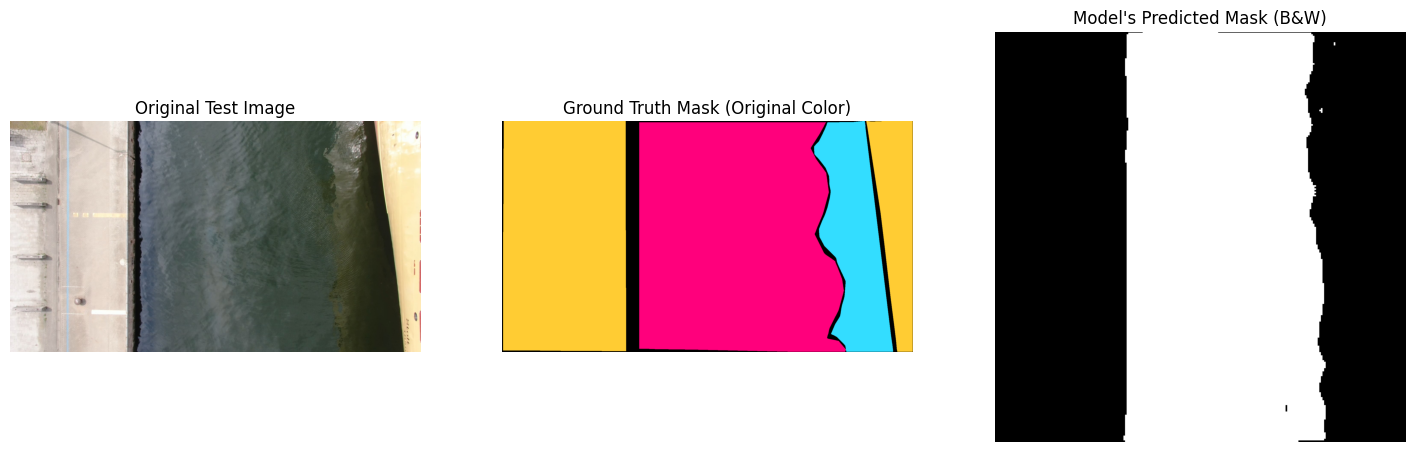

In [ ]:
import random
import os
import cv2
import matplotlib.pyplot as plt

# --- CHOOSE AN IMAGE TO TEST ---
# Get a random image from the test set
test_image_name = random.choice(os.listdir(test_imgs_path))
test_image_path = os.path.join(test_imgs_path, test_image_name)

# --- GET PREDICTION ---
classification, predicted_mask = predict_spill(model, test_image_path, device)

# --- VISUALIZE THE RESULTS ---
# Load the original image for display
original_image = cv2.cvtColor(cv2.imread(test_image_path), cv2.COLOR_BGR2RGB)

# Load the original, multi-colored ground truth mask for display
gt_mask_name = test_image_name.replace('.jpg', '.png')
gt_mask_path = os.path.join(test_masks_path, gt_mask_name)
ground_truth_mask_color = cv2.cvtColor(cv2.imread(gt_mask_path, cv2.IMREAD_COLOR), cv2.COLOR_BGR2RGB)

# Display the results
print(f"Image: {test_image_name}")
print(f"Model Prediction: {classification}")

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))

ax1.imshow(original_image)
ax1.set_title("Original Test Image")
ax1.axis("off")

ax2.imshow(ground_truth_mask_color)
ax2.set_title("Ground Truth Mask (Original Color)")
ax2.axis("off")

ax3.imshow(predicted_mask, cmap='gray')
ax3.set_title("Model's Predicted Mask (B&W)")
ax3.axis("off")

plt.show()

In [ ]:
import os
from tqdm import tqdm

# A list to store the filenames of images classified as "no spill"
no_spill_predictions = []

print(f"--- Running inference on all {len(os.listdir(test_imgs_path))} test images ---")

# Loop through every single image file in the test directory
for image_name in tqdm(os.listdir(test_imgs_path)):
    # Make sure we're only processing image files
    if image_name.endswith('.jpg'):
        image_path = os.path.join(test_imgs_path, image_name)

        # Use our predict_spill function to get the classification
        classification, _ = predict_spill(model, image_path, device)

        # If the model classified it as "No Spill", add the filename to our list
        if classification == "No Spill Detected":
            no_spill_predictions.append(image_name)

print("\n--- Inference Complete ---")
print(f"The model classified {len(no_spill_predictions)} images as 'No Spill Detected'.")
print("\nHere are the filenames:")

# Print the list of filenames
for filename in no_spill_predictions:
    print(f"- {filename}")

--- Running inference on all 254 test images ---


100%|██████████| 254/254 [00:09<00:00, 26.34it/s]


--- Inference Complete ---
The model classified 45 images as 'No Spill Detected'.

Here are the filenames:
- Oil (27).jpg
- Oil (127).jpg
- Oil (74).jpg
- Oil (115).jpg
- Oil (166).jpg
- Oil (175).jpg
- Oil (218).jpg
- Oil (203).jpg
- Oil (184).jpg
- Oil (145).jpg
- Oil (131).jpg
- Oil (4).jpg
- Oil (112).jpg
- Oil (237).jpg
- Oil (135).jpg
- Oil (182).jpg
- Oil (14).jpg
- Oil (194).jpg
- Oil (240).jpg
- Oil (21).jpg
- Oil (167).jpg
- Oil (179).jpg
- Oil (71).jpg
- Oil (30).jpg
- Oil (210).jpg
- Oil (133).jpg
- Oil (231).jpg
- Oil (142).jpg
- Oil (165).jpg
- Oil (128).jpg
- Oil (177).jpg
- Oil (144).jpg
- Oil (109).jpg
- Oil (79).jpg
- Oil (239).jpg
- Oil (162).jpg
- Oil (161).jpg
- Oil (200).jpg
- Oil (48).jpg
- Oil (235).jpg
- Oil (134).jpg
- Oil_2 (10).jpg
- Oil (187).jpg
- Oil (148).jpg
- Oil_2 (9).jpg


In [ ]:
import os
import shutil
from google.colab import files


filenames_to_copy = no_spill_predictions

source_dir = test_imgs_path

destination_dir = "/content/no_oil_spill1"


os.makedirs(destination_dir, exist_ok=True)
print(f"Created directory: {destination_dir}")

files_copied_count = 0
for filename in filenames_to_copy:
    source_path = os.path.join(source_dir, filename)
    destination_path = os.path.join(destination_dir, filename)


    if os.path.exists(source_path):
        shutil.copy(source_path, destination_path)
        files_copied_count += 1

print(f"\nSuccessfully copied {files_copied_count} images to the '{destination_dir}' folder.")


Created directory: /content/no_oil_spill1

Successfully copied 45 images to the '/content/no_oil_spill1' folder.


In [ ]:
import os
from tqdm import tqdm
import numpy as np
import cv2

# Initialize counters for our analysis
true_positives = 0  # Model said "Spill" and it was a "Spill"
true_negatives = 0  # Model said "No Spill" and it was "No Spill"
false_positives = 0 # Model said "Spill" but it was "No Spill" (like the sun glint image)
false_negatives = 0 # Model said "No Spill" but it was a "Spill" (a missed detection)

print(f"--- Analyzing all {len(os.listdir(test_imgs_path))} test images ---")

# Loop through every image in the test set
for image_name in tqdm(os.listdir(test_imgs_path)):
    if not image_name.endswith('.jpg'):
        continue

    # --- 1. Determine the Ground Truth ---
    mask_name = image_name.replace('.jpg', '.png')
    mask_path = os.path.join(test_masks_path, mask_name)
    gt_mask = cv2.imread(mask_path, cv2.IMREAD_COLOR)

    ground_truth_is_spill = False
    if gt_mask is not None and gt_mask.ndim == 3:
        if np.any(np.all(gt_mask == OIL_SPILL_COLOR_BGR, axis=2)):
            ground_truth_is_spill = True

    # --- 2. Get the Model's Prediction ---
    image_path = os.path.join(test_imgs_path, image_name)
    classification, _ = predict_spill(model, image_path, device)
    prediction_is_spill = (classification == "Oil Spill Detected")

    # --- 3. Compare and update counters ---
    if prediction_is_spill and ground_truth_is_spill:
        true_positives += 1
    elif not prediction_is_spill and not ground_truth_is_spill:
        true_negatives += 1
    elif prediction_is_spill and not ground_truth_is_spill:
        false_positives += 1
    elif not prediction_is_spill and ground_truth_is_spill:
        false_negatives += 1

# --- 4. Print the final report ---
total_test_images = len(os.listdir(test_imgs_path))
total_true_spills = true_positives + false_negatives
total_true_no_spills = true_negatives + false_positives

print("\n--- Test Set Analysis Complete ---")
print("\n## Ground Truth Counts ##")
print(f"- Total Images with Oil Spill:    {total_true_spills}")
print(f"- Total Images with No Oil Spill:   {total_true_no_spills}")
print("-" * 35)
print(f"Total Test Images:                {total_test_images}")

print("\n## Model Performance Breakdown ##")
print(f"✅ Correctly identified 'No Spill' (True Negatives):    {true_negatives}")
print(f"✅ Correctly identified 'Oil Spill' (True Positives):   {true_positives}")
print(f"❌ Incorrectly called 'No Spill' an 'Oil Spill' (False Positives): {false_positives}")
print(f"❌ Incorrectly called 'Oil Spill' a 'No Spill' (False Negatives): {false_negatives}")

--- Analyzing all 254 test images ---


100%|██████████| 254/254 [00:37<00:00,  6.69it/s]


--- Test Set Analysis Complete ---

## Ground Truth Counts ##
- Total Images with Oil Spill:    202
- Total Images with No Oil Spill:   52
-----------------------------------
Total Test Images:                254

## Model Performance Breakdown ##
✅ Correctly identified 'No Spill' (True Negatives):    42
✅ Correctly identified 'Oil Spill' (True Positives):   199
❌ Incorrectly called 'No Spill' an 'Oil Spill' (False Positives): 10
❌ Incorrectly called 'Oil Spill' a 'No Spill' (False Negatives): 3


--- Running Robustness Check on: Oil (194).jpg ---


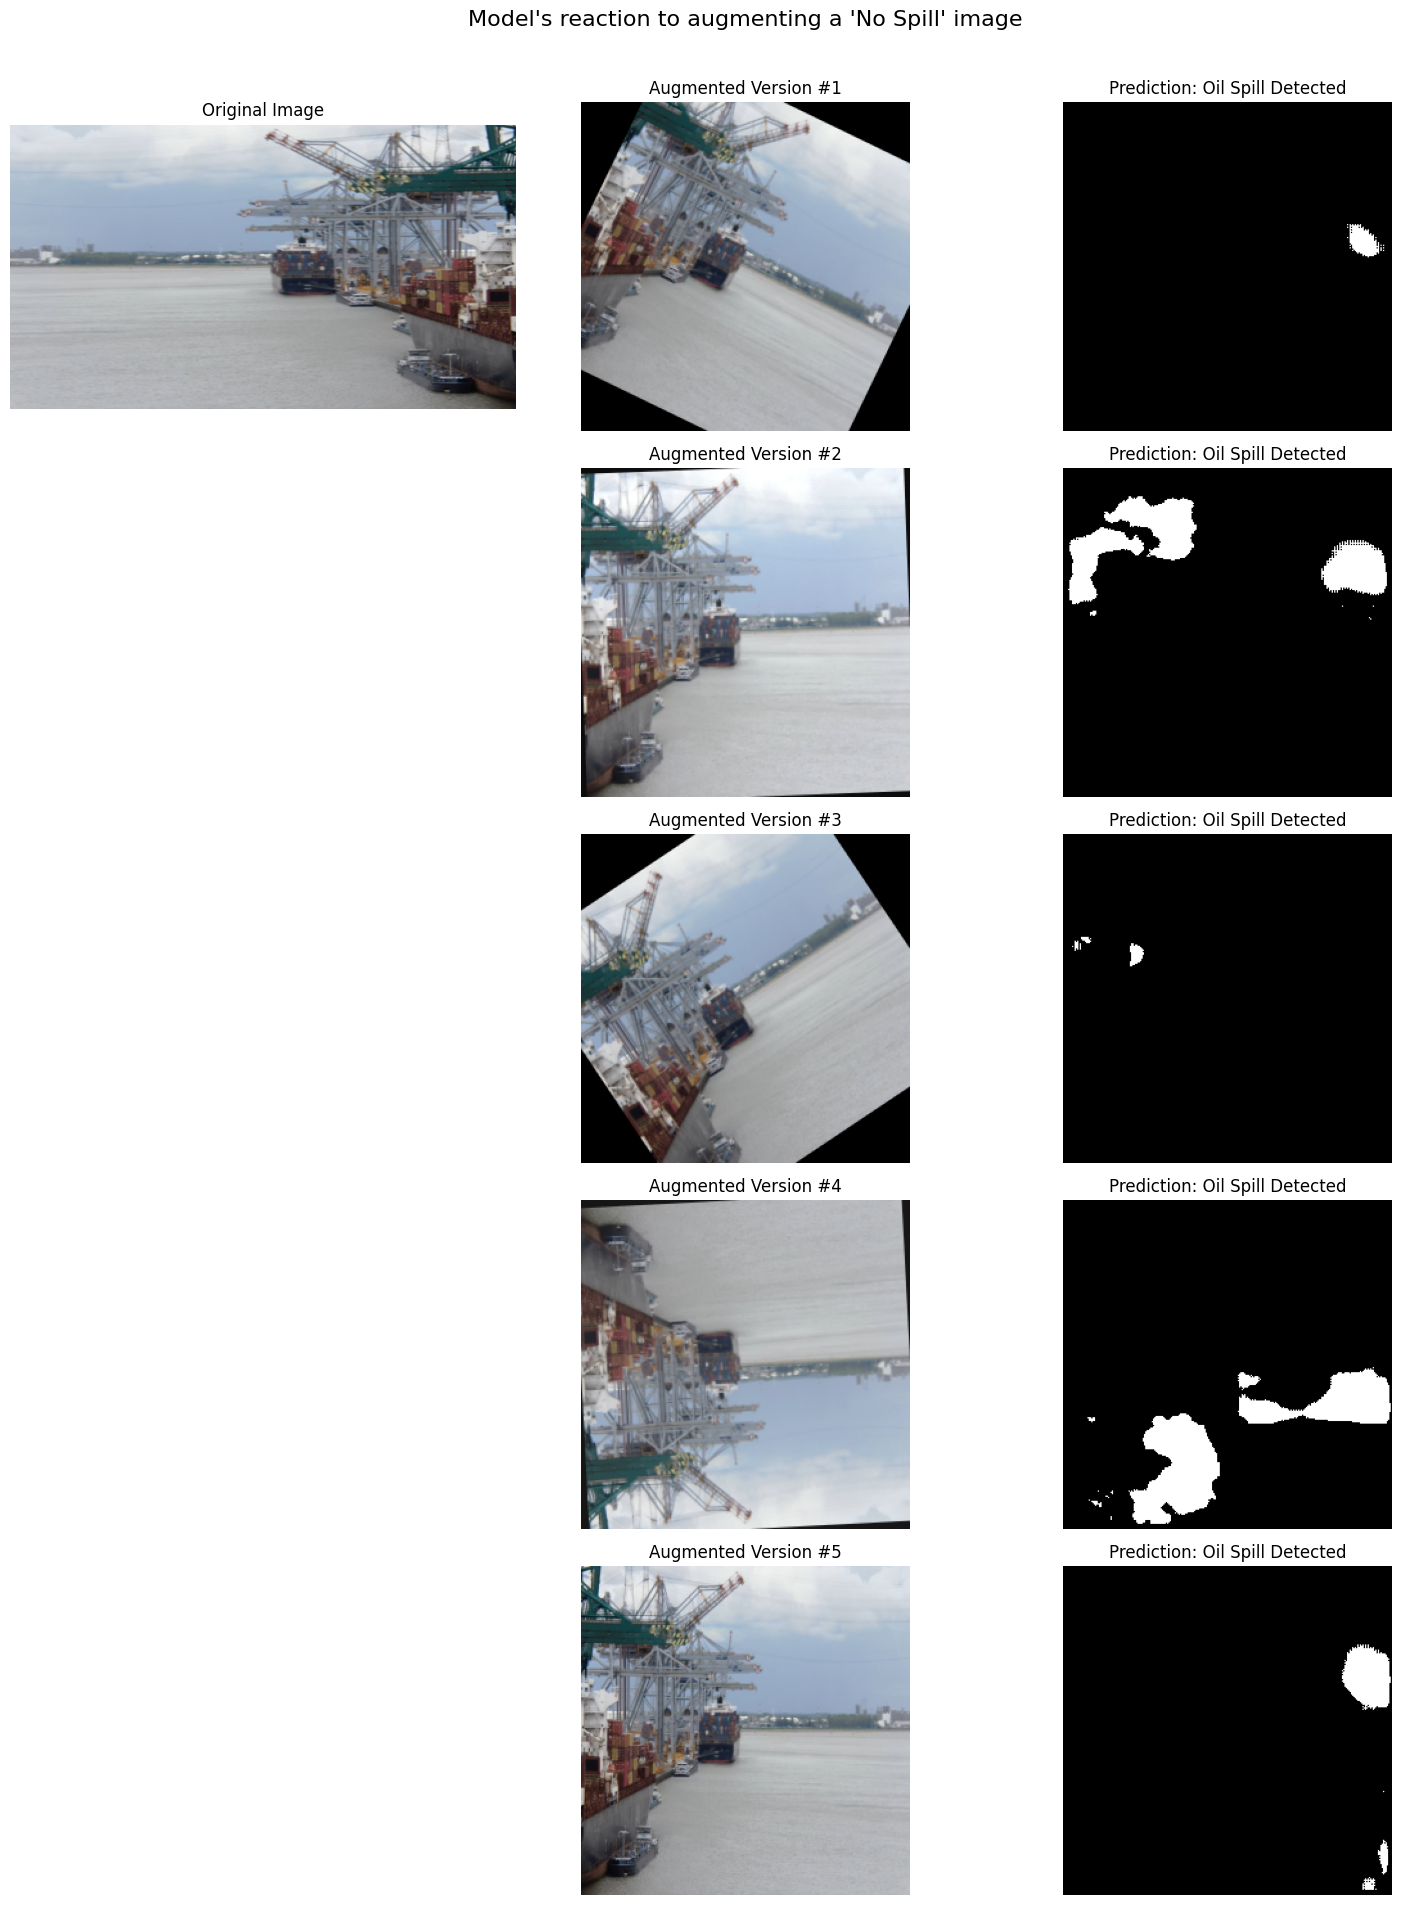

In [ ]:
import random
import numpy as np

# --- 1. Find the true "no spill" images from the test set ---
# (We can reuse the logic from our analysis cell)
true_no_spill_filenames = []
for image_name in os.listdir(test_imgs_path):
    if not image_name.endswith('.jpg'):
        continue
    mask_name = image_name.replace('.jpg', '.png')
    mask_path = os.path.join(test_masks_path, mask_name)
    gt_mask = cv2.imread(mask_path, cv2.IMREAD_COLOR)

    is_spill = False
    if gt_mask is not None and gt_mask.ndim == 3:
        if np.any(np.all(gt_mask == OIL_SPILL_COLOR_BGR, axis=2)):
            is_spill = True
    if not is_spill:
        true_no_spill_filenames.append(image_name)

# --- 2. Pick one "no spill" image to experiment on ---
image_to_test_name = random.choice(true_no_spill_filenames)
image_to_test_path = os.path.join(test_imgs_path, image_to_test_name)
original_image = cv2.cvtColor(cv2.imread(image_to_test_path), cv2.COLOR_BGR2RGB)

print(f"--- Running Robustness Check on: {image_to_test_name} ---")

# --- 3. Apply augmentation 5 times and get a prediction for each ---
num_augmentations = 5
fig, axes = plt.subplots(num_augmentations, 3, figsize=(15, 20))
fig.suptitle(f"Model's reaction to augmenting a 'No Spill' image", fontsize=16)


for i in range(num_augmentations):
    # Apply the heavy augmentation pipeline
    augmented = no_spill_transform(image=original_image)
    input_tensor = augmented['image'].unsqueeze(0).to(device)

    # Get the model's prediction
    model.eval()
    with torch.no_grad():
        logits = model(input_tensor)
        probs = torch.sigmoid(logits)
        prediction = (probs > 0.5).float()

    # Determine classification and get the mask
    if torch.sum(prediction) > 0:
        classification = "Oil Spill Detected"
    else:
        classification = "No Spill Detected"
    predicted_mask = prediction.squeeze(0).squeeze(0).cpu().numpy()

    # Visualize the results
    ax_orig, ax_aug, ax_pred = axes[i]
    if i == 0: # Show the original image in the first row for reference
        ax_orig.imshow(original_image)
        ax_orig.set_title("Original Image")
    ax_orig.axis("off")

    ax_aug.imshow(augmented['image'].permute(1, 2, 0).numpy())
    ax_aug.set_title(f"Augmented Version #{i+1}")
    ax_aug.axis("off")

    ax_pred.imshow(predicted_mask, cmap='gray')
    ax_pred.set_title(f"Prediction: {classification}")
    ax_pred.axis("off")

plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()

In [ ]:
import cv2
import matplotlib.pyplot as plt

custom_image_path = "/content/oil_spill_t1.jpg"


try:

    classification, predicted_mask = predict_spill(model, custom_image_path, device)


    original_image = cv2.cvtColor(cv2.imread(custom_image_path), cv2.COLOR_BGR2RGB)

    print(f"--- Prediction for Custom Image ---")
    print(f"File: {custom_image_path}")
    print(f"Model's Classification: {classification}")

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

    ax1.imshow(original_image)
    ax1.set_title("Your Custom Image")
    ax1.axis("off")

    ax2.imshow(predicted_mask, cmap='gray')
    ax2.set_title("Model's Predicted Mask")
    ax2.axis("off")

    plt.show()

except FileNotFoundError:
    print(f"ERROR: File not found at '{custom_image_path}'")
    print("Please make sure you have uploaded the file and pasted the correct path.")
except Exception as e:
    print(f"An error occurred: {e}")

In [ ]:
import os
from tqdm import tqdm
import numpy as np
import cv2

# Initialize counters for our analysis
true_positives = 0  # Model said "Spill" and it was a "Spill"
true_negatives = 0  # Model said "No Spill" and it was "No Spill"
false_positives = 0 # Model said "Spill" but it was "No Spill" (like the sun glint image)
false_negatives = 0 # Model said "No Spill" but it was a "Spill" (a missed detection)

print(f"--- Analyzing all {len(os.listdir(test_imgs_path))} test images ---")

# Loop through every image in the test set
for image_name in tqdm(os.listdir(test_imgs_path)):
    if not image_name.endswith('.jpg'):
        continue

    # --- 1. Determine the Ground Truth ---
    mask_name = image_name.replace('.jpg', '.png')
    mask_path = os.path.join(test_masks_path, mask_name)
    gt_mask = cv2.imread(mask_path, cv2.IMREAD_COLOR)

    ground_truth_is_spill = False
    if gt_mask is not None and gt_mask.ndim == 3:
        if np.any(np.all(gt_mask == OIL_SPILL_COLOR_BGR, axis=2)):
            ground_truth_is_spill = True

    # --- 2. Get the Model's Prediction ---
    image_path = os.path.join(test_imgs_path, image_name)
    classification, _ = predict_spill(model, image_path, device)
    prediction_is_spill = (classification == "Oil Spill Detected")

    # --- 3. Compare and update counters ---
    if prediction_is_spill and ground_truth_is_spill:
        true_positives += 1
    elif not prediction_is_spill and not ground_truth_is_spill:
        true_negatives += 1
    elif prediction_is_spill and not ground_truth_is_spill:
        false_positives += 1
    elif not prediction_is_spill and ground_truth_is_spill:
        false_negatives += 1

# --- 4. Print the final report ---
total_test_images = len(os.listdir(test_imgs_path))
total_true_spills = true_positives + false_negatives
total_true_no_spills = true_negatives + false_positives

print("\n--- Test Set Analysis Complete ---")
print("\n## Ground Truth Counts ##")
print(f"- Total Images with Oil Spill:    {total_true_spills}")
print(f"- Total Images with No Oil Spill:   {total_true_no_spills}")
print("-" * 35)
print(f"Total Test Images:                {total_test_images}")

print("\n## Model Performance Breakdown ##")
print(f"✅ Correctly identified 'No Spill' (True Negatives):    {true_negatives}")
print(f"✅ Correctly identified 'Oil Spill' (True Positives):   {true_positives}")
print(f"❌ Incorrectly called 'No Spill' an 'Oil Spill' (False Positives): {false_positives}")
print(f"❌ Incorrectly called 'Oil Spill' a 'No Spill' (False Negatives): {false_negatives}")

--- Analyzing all 254 test images ---


100%|██████████| 254/254 [00:36<00:00,  6.87it/s]


--- Test Set Analysis Complete ---

## Ground Truth Counts ##
- Total Images with Oil Spill:    202
- Total Images with No Oil Spill:   52
-----------------------------------
Total Test Images:                254

## Model Performance Breakdown ##
✅ Correctly identified 'No Spill' (True Negatives):    33
✅ Correctly identified 'Oil Spill' (True Positives):   200
❌ Incorrectly called 'No Spill' an 'Oil Spill' (False Positives): 19
❌ Incorrectly called 'Oil Spill' a 'No Spill' (False Negatives): 2


Please select an image file to upload for oil spill detection.


Saving Oil (1).jpg to Oil (1).jpg

Image 'Oil (1).jpg' uploaded successfully.
Running prediction...

--- Prediction Complete ---
File: Oil (1).jpg
Model's Classification: Oil Spill Detected


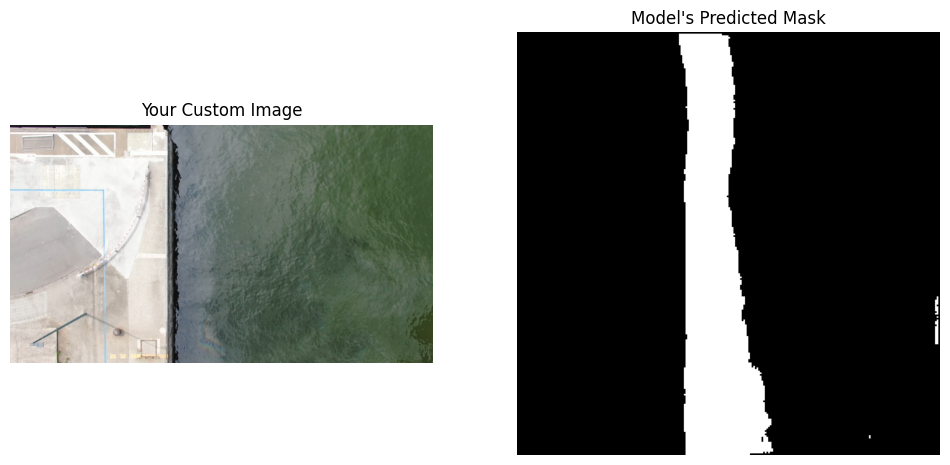

In [ ]:
from google.colab import files
import matplotlib.pyplot as plt
import cv2
import os

def test_on_custom_image():
    """
    Handles uploading a custom image, running prediction, and visualizing the result.
    Assumes the 'model', 'device', and 'predict_spill' function are already defined.
    """
    print("Please select an image file to upload for oil spill detection.")

    # Open a file upload dialog
    uploaded = files.upload()

    # Check if a file was selected
    if not uploaded:
        print("\nNo file was selected. Please run the cell again to try again.")
        return

    # Get the filename and save the uploaded file to a temporary path
    filename = next(iter(uploaded))
    temp_image_path = os.path.join("/content/", filename)
    with open(temp_image_path, 'wb') as f:
        f.write(uploaded[filename])

    print(f"\nImage '{filename}' uploaded successfully.")
    print("Running prediction...")

    try:
        # Use the predict_spill function we defined earlier
        classification, predicted_mask = predict_spill(model, temp_image_path, device)

        # --- Visualize the results ---
        original_image = cv2.cvtColor(cv2.imread(temp_image_path), cv2.COLOR_BGR2RGB)

        print("\n--- Prediction Complete ---")
        print(f"File: {filename}")
        print(f"Model's Classification: {classification}")

        # Display the original image and the model's prediction side-by-side
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

        ax1.imshow(original_image)
        ax1.set_title("Your Custom Image")
        ax1.axis("off")

        ax2.imshow(predicted_mask, cmap='gray')
        ax2.set_title("Model's Predicted Mask")
        ax2.axis("off")

        plt.show()

    except Exception as e:
        print(f"\nAn error occurred during prediction: {e}")
        print("Please ensure the uploaded file is a valid image format (e.g., .jpg, .png).")
    finally:
        # Clean up by removing the temporary image file
        if os.path.exists(temp_image_path):
            os.remove(temp_image_path)

# --- Run the function ---
test_on_custom_image()

In [ ]:
import torch
from tqdm import tqdm
import numpy as np


def calculate_iou(preds, labels, smooth=1e-6):
   "

    preds = preds.view(-1)
    labels = labels.view(-1)

    # Calculate intersection (pixels that are 1 in BOTH prediction and label)
    intersection = (preds * labels).sum()

    # Calculate union (pixels that are 1 in EITHER prediction or label)
    total = (preds + labels).sum()
    union = total - intersection

    # Calculate IoU, adding a small epsilon to avoid division by zero
    iou = (intersection + smooth) / (union + smooth)

    return iou

def evaluate_iou_on_test_set(model, test_loader, device):

    print("--- Calculating Intersection over Union (IoU) on the Test Set ---")

    # Set the model to evaluation mode
    model.eval()

    total_iou_score = 0.0

    # Disable gradient calculations to save memory and speed up
    with torch.no_grad():
        # Loop through all batches in the test loader
        for x, y in tqdm(test_loader):
            # Move data to the GPU/CPU
            x = x.to(device)
            y = y.to(device)

            # Get the model's raw output (logits)
            logits = model(x)

            # Convert logits to probabilities (0-1) and then to a binary mask (0 or 1)
            preds = torch.sigmoid(logits)
            preds = (preds > 0.5).float()

            # Calculate IoU for the current batch and add it to the total
            batch_iou = calculate_iou(preds, y)
            total_iou_score += batch_iou


    avg_iou = total_iou_score / len(test_loader)

    print("\n--- IoU Calculation Complete ---")
    print(f"Average Intersection over Union (IoU) on the test set: {avg_iou:.4f}")

    return avg_iou

iou_result = evaluate_iou_on_test_set(model, test_loader, device)

--- Calculating Intersection over Union (IoU) on the Test Set ---


100%|██████████| 16/16 [00:32<00:00,  2.02s/it]



--- IoU Calculation Complete ---
Average Intersection over Union (IoU) on the test set: 0.8806


In [ ]:
%%writefile app.py

import streamlit as st
import torch
import torch.nn as nn
import torchvision.transforms.functional as TF
import albumentations as A
from albumentations.pytorch import ToTensorV2
import numpy as np
from PIL import Image
import cv2


st.set_page_config(
    page_title="Oil Spill Segmentation",
    page_icon="🌊",
    layout="wide"
)


IMG_SIZE = (256, 256)
MODEL_PATH = 'best_model.pth'
MIN_SPILL_AREA_PIXELS = 500




class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(DoubleConv, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, 1, 1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, 1, 1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.conv(x)

class UNET(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, features=[64, 128, 256, 512]):
        super(UNET, self).__init__()
        self.ups = nn.ModuleList()
        self.downs = nn.ModuleList()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        for feature in features:
            self.downs.append(DoubleConv(in_channels, feature))
            in_channels = feature
        for feature in reversed(features):
            self.ups.append(nn.ConvTranspose2d(feature*2, feature, kernel_size=2, stride=2))
            self.ups.append(DoubleConv(feature*2, feature))
        self.bottleneck = DoubleConv(features[-1], features[-1]*2)
        self.final_conv = nn.Conv2d(features[0], out_channels, kernel_size=1)

    def forward(self, x):
        skip_connections = []
        for down in self.downs:
            x = down(x)
            skip_connections.append(x)
            x = self.pool(x)
        x = self.bottleneck(x)
        skip_connections = skip_connections[::-1]
        for idx in range(0, len(self.ups), 2):
            x = self.ups[idx](x)
            skip_connection = skip_connections[idx//2]
            if x.shape != skip_connection.shape:
                x = TF.resize(x, size=skip_connection.shape[2:])
            concat_skip = torch.cat((skip_connection, x), dim=1)
            x = self.ups[idx+1](concat_skip)
        return self.final_conv(x)


base_transform = A.Compose([
    A.Resize(height=IMG_SIZE[0], width=IMG_SIZE[1]),
    A.Normalize(mean=[0.0, 0.0, 0.0], std=[1.0, 1.0, 1.0], max_pixel_value=255.0),
    ToTensorV2(),
])




@st.cache_resource
def load_pytorch_model():

    try:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        model = UNET(in_channels=3, out_channels=1).to(device)
        model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
        model.eval()
        return model, device
    except Exception as e:
        st.error(f"Error loading PyTorch model: {e}")
        st.error(f"Please make sure the model file '{MODEL_PATH}' is in the same directory.")
        return None, None




def predict_and_analyze(model, device, image_bytes):

    pil_image = Image.open(image_bytes).convert('RGB')
    image_np = np.array(pil_image)

    transformed = base_transform(image=image_np)
    input_tensor = transformed['image'].unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(input_tensor)
        probs = torch.sigmoid(logits)
        predicted_mask_tensor = (probs > 0.5).float()


    spill_pixel_count = torch.sum(predicted_mask_tensor).item()
    if spill_pixel_count > MIN_SPILL_AREA_PIXELS:
        status = f"Oil Spill Detected ({int(spill_pixel_count)} spill pixels found)"
        status_color = "red"

        final_binary_mask_np = predicted_mask_tensor.squeeze().cpu().numpy()
    else:
        status = "No Spill Detected"
        status_color = "green"

        final_binary_mask_np = np.zeros_like(predicted_mask_tensor.squeeze().cpu().numpy())


    resized_original_image_for_overlay = cv2.resize(image_np, IMG_SIZE, interpolation=cv2.INTER_AREA)


    OIL_SPILL_COLOR_BGR = (0, 0, 255)
    ALPHA = 0.5


    colored_spill_mask = np.zeros_like(resized_original_image_for_overlay, dtype=np.uint8)

    colored_spill_mask[final_binary_mask_np == 1] = OIL_SPILL_COLOR_BGR


    resized_original_image_bgr = cv2.cvtColor(resized_original_image_for_overlay, cv2.COLOR_RGB2BGR)

    overlay_image_bgr = cv2.addWeighted(resized_original_image_bgr, 1 - ALPHA, colored_spill_mask, ALPHA, 0)


    overlay_image_rgb = cv2.cvtColor(overlay_image_bgr, cv2.COLOR_BGR2RGB)


    original_image_for_display = pil_image.resize(IMG_SIZE)

    return original_image_for_display, overlay_image_rgb, status, status_color




st.title("🌊 Oil Spill Detection System (PyTorch)")
st.markdown("Upload a satellite image to segment and analyze for potential oil spills.")

model, device = load_pytorch_model()

if model:
    uploaded_file = st.file_uploader("Choose an image...", type=["jpg", "png", "jpeg"])
    if uploaded_file is not None:
        with st.spinner('Analyzing the image...'):
            original_image, predicted_mask, status, status_color = predict_and_analyze(model, device, uploaded_file)

        st.markdown(f'<h2 style="color:{status_color}; text-align:center;">{status}</h2>', unsafe_allow_html=True)

        col1, col2 = st.columns(2)
        with col1:
            st.image(original_image, caption='Original Uploaded Image', use_container_width=True)
        with col2:
            st.image(predicted_mask, caption='Oil Spill Overlay', use_container_width=True)

        st.success("Analysis complete!")
else:
    st.warning("Model could not be loaded. The application cannot proceed.")


Overwriting app.py


In [ ]:
!pip install -q streamlit
!pip install -q pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 35.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 15.5 MB/s eta 0:00:00


In [ ]:
from pyngrok import ngrok


ngrok.kill()


NGROK_AUTH_TOKEN = "32mH2IqTr4HU1HOLA3MTYzRPogS_7kvTqQd74XXaSyf4UR4Sj"
ngrok.set_auth_token(NGROK_AUTH_TOKEN)


public_url = ngrok.connect(8501)
print(f"Streamlit App URL: {public_url}")


!streamlit run app.py

Streamlit App URL: NgrokTunnel: "https://7080df23cc7e.ngrok-free.app" -> "http://localhost:8501"



  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://35.247.173.221:8501

2025-09-30 19:44:14.658 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`, use `width='content'`.
2025-09-30 19:44:14.660 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`, use `width='content'`.
  Stopping...
  Stopping...
